In [11]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
from scipy.signal import find_peaks

In [3]:
stolen_water = pd.read_csv('./csvs/consum cu posibil furt de apă.csv', sep=';')
# stolen_water.describe()

stolen_water['x'] = pd.to_datetime(stolen_water['x'], format='%d/%m/%Y %H:%M')
stolen_water['Date'] = pd.to_datetime(stolen_water['x']).dt.date.astype('datetime64[ns]')
stolen_water['Hour'] = pd.to_datetime(stolen_water['x'], format='%d/%m/%Y %H:%M').dt.hour

stolen_water.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   x       398 non-null    datetime64[ns]
 1   y       398 non-null    int64         
 2   Date    398 non-null    datetime64[ns]
 3   Hour    398 non-null    int32         
dtypes: datetime64[ns](2), int32(1), int64(1)
memory usage: 11.0 KB


In [ ]:
stolen_water[stolen_water['Date'] == '2025-03-19']

,x,y,Date,Hour
0,2025-03-19 08:00:00,94,2025-03-19,8
1,2025-03-19 09:00:00,196,2025-03-19,9
2,2025-03-19 10:00:00,146,2025-03-19,10
3,2025-03-19 11:00:00,231,2025-03-19,11
4,2025-03-19 12:00:00,195,2025-03-19,12
5,2025-03-19 13:00:00,213,2025-03-19,13
6,2025-03-19 14:00:00,168,2025-03-19,14
7,2025-03-19 15:00:00,124,2025-03-19,15
8,2025-03-19 16:00:00,83,2025-03-19,16
9,2025-03-19 17:00:00,103,2025-03-19,17


In [96]:
stolen_water.describe()

,x,y,Date,Hour
count,398,398.000000,398,398.000000
mean,2025-03-27 14:51:06.331658240,88.952261,2025-03-27 03:11:45.527638272,11.655779
min,2025-03-19 08:00:00,3.000000,2025-03-19 00:00:00,0.000000
25%,2025-03-23 11:15:00,11.000000,2025-03-23 00:00:00,6.000000
50%,2025-03-27 14:30:00,14.000000,2025-03-27 00:00:00,12.000000
75%,2025-03-31 18:45:00,119.250000,2025-03-31 00:00:00,18.000000
max,2025-04-04 22:00:00,792.000000,2025-04-04 00:00:00,23.000000
std,NaN,149.874692,NaN,6.874888


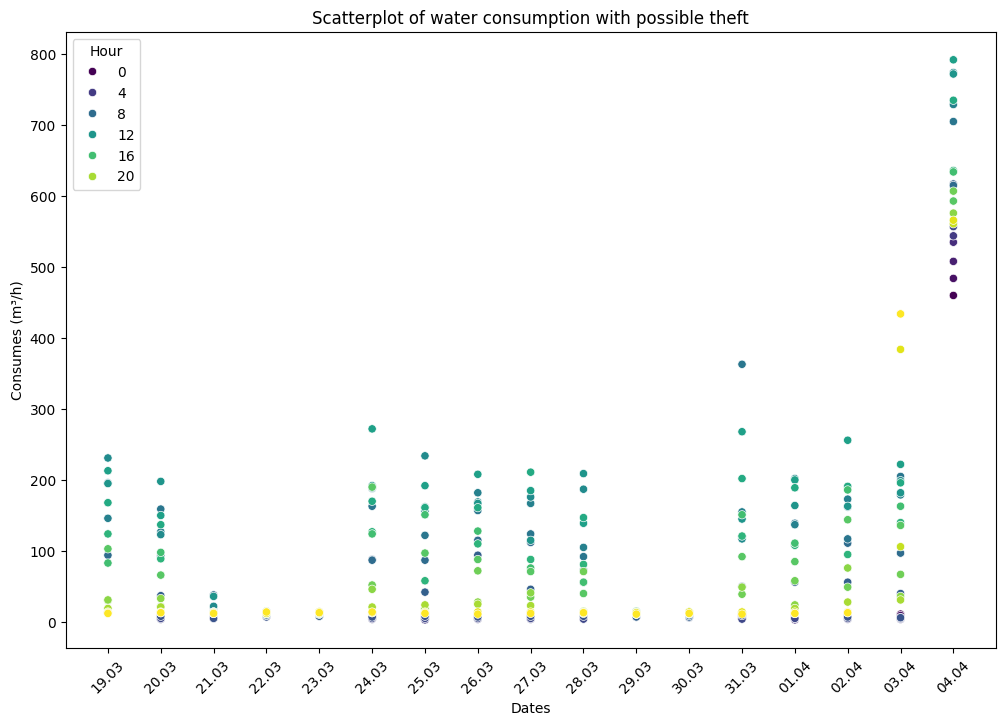

In [ ]:
plt.pyplot.figure(figsize=(12, 8))
sns.scatterplot(data=stolen_water, x='Date', y='y', hue='Hour', palette='viridis')

# Formatează axa x pentru a afișa fiecare zi
unique_dates = stolen_water['Date'].drop_duplicates().sort_values()
formatted_dates = [pd.to_datetime(date).strftime('%d.%m') for date in unique_dates]
plt.pyplot.xticks(ticks=unique_dates, labels=formatted_dates, rotation=45)

# Adaugă titlu, etichete și legendă
plt.pyplot.title('Scatterplot of water consumption with possible theft', fontsize=12)
plt.pyplot.xlabel('Dates', fontsize=10)
plt.pyplot.ylabel('Consumes (m³/h)', fontsize=10)
plt.pyplot.legend(title='Hour', fontsize=10)

plt.pyplot.show()

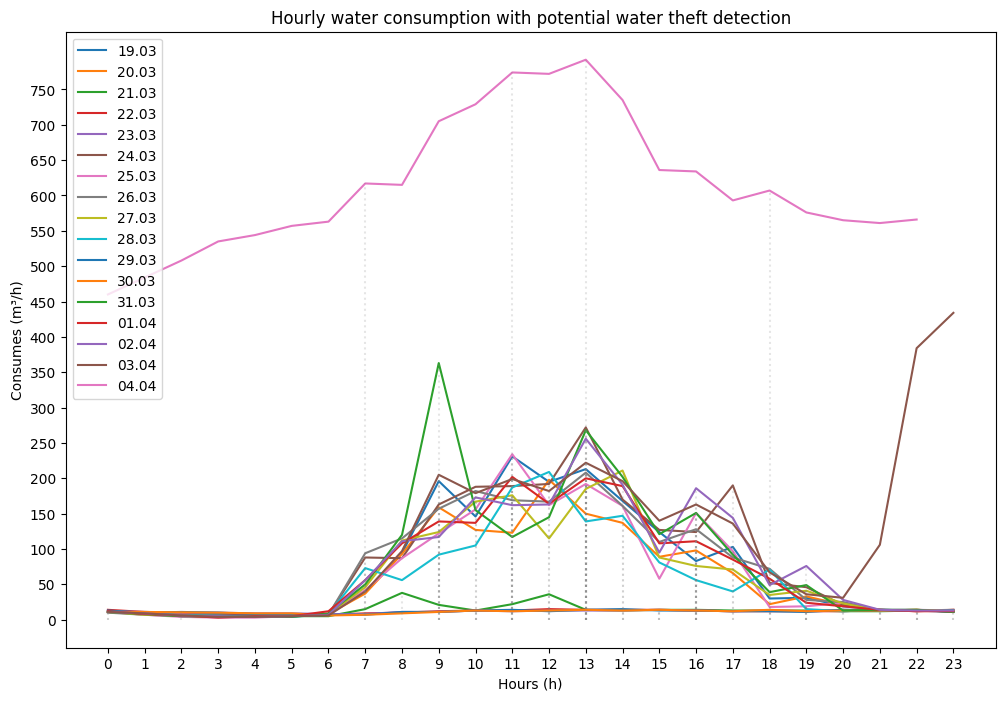

In [ ]:
peak_indices, _ = find_peaks(stolen_water['y'])
peaks = stolen_water.iloc[peak_indices]

plt.pyplot.figure(figsize=(12, 8))
for date, group in stolen_water.groupby('Date'):
    formatted_date = pd.to_datetime(date).strftime('%d.%m')
    plt.pyplot.plot(group['Hour'], group['y'], label=formatted_date)

# Adaugă linii punctate de la vârfuri până la axa x
for _, peak in peaks.iterrows():
    plt.pyplot.vlines(x=peak['Hour'], ymin=0, ymax=peak['y'], linestyles='dotted', colors='gray' ,alpha=0.2)

plt.pyplot.xlabel('Hours (h)', fontsize=10)
plt.pyplot.ylabel('Consumes (m³/h)', fontsize=10)

plt.pyplot.xticks(np.arange(0, stolen_water["Hour"].max() + 1, 1))
plt.pyplot.yticks(np.arange(0, stolen_water["y"].max() + 1, 50))

plt.pyplot.legend()
plt.pyplot.title('Hourly water consumption with potential water theft detection', fontsize=12)

plt.pyplot.show()

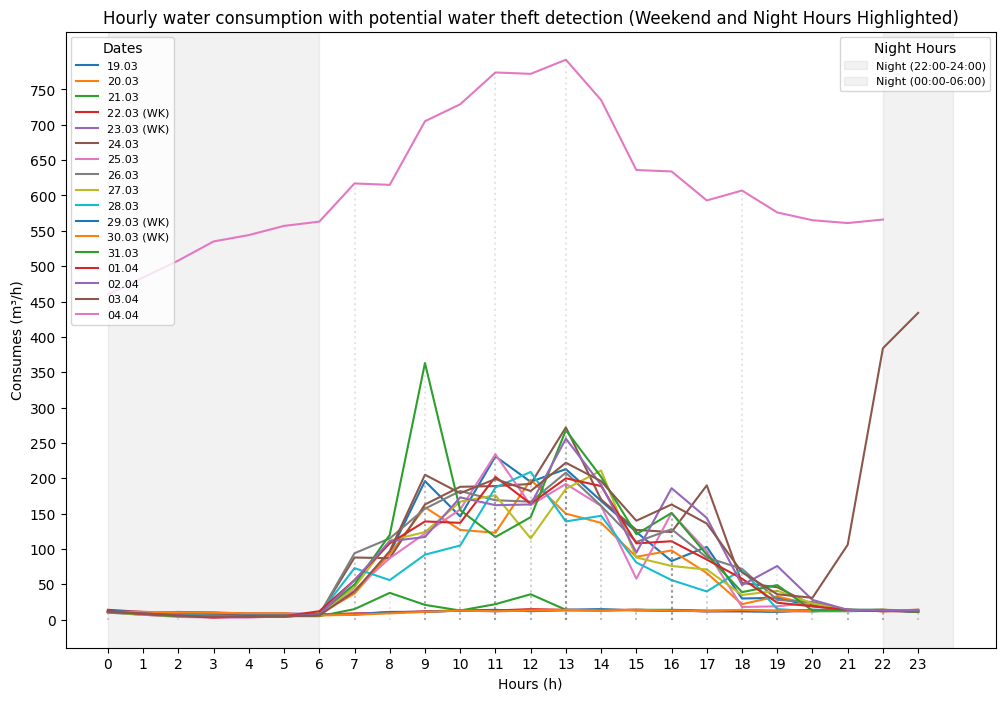

In [19]:
weekend_dates = stolen_water[stolen_water['Date'].dt.dayofweek >= 5]['Date'].unique()

peak_indices, _ = find_peaks(stolen_water['y'])
peaks = stolen_water.iloc[peak_indices]

plt.pyplot.figure(figsize=(12, 8))

# Plot data for each date
for date, group in stolen_water.groupby('Date'):
    formatted_date = pd.to_datetime(date).strftime('%d.%m')
    if date in weekend_dates:
        plt.pyplot.plot(group['Hour'], group['y'], label=f"{formatted_date} (WK)")
    else:
        plt.pyplot.plot(group['Hour'], group['y'], label=formatted_date)

# Highlight night intervals (22:00-06:00)
night_1 = plt.pyplot.axvspan(22, 24, color='gray', alpha=0.1)
night_2 = plt.pyplot.axvspan(0, 6, color='gray', alpha=0.1)

# Add dotted lines for peaks and annotate consumption
for _, peak in peaks.iterrows():
    plt.pyplot.vlines(x=peak['Hour'], ymin=0, ymax=peak['y'], linestyles='dotted', colors='gray', alpha=0.2)

plt.pyplot.xlabel('Hours (h)', fontsize=10)
plt.pyplot.ylabel('Consumes (m³/h)', fontsize=10)

plt.pyplot.xticks(np.arange(0, stolen_water["Hour"].max() + 1, 1))
plt.pyplot.yticks(np.arange(0, stolen_water["y"].max() + 1, 50))

# Add legends
data_legend = plt.pyplot.legend(fontsize=8, loc='upper left', title="Dates")
plt.pyplot.gca().add_artist(data_legend)  # Keep the first legend

night_legend = plt.pyplot.legend([night_1, night_2], ["Night (22:00-24:00)", "Night (00:00-06:00)"], 
                                 fontsize=8, loc='upper right', title="Night Hours")

plt.pyplot.title('Hourly water consumption with potential water theft detection (Weekend and Night Hours Highlighted)', fontsize=12)

plt.pyplot.show()

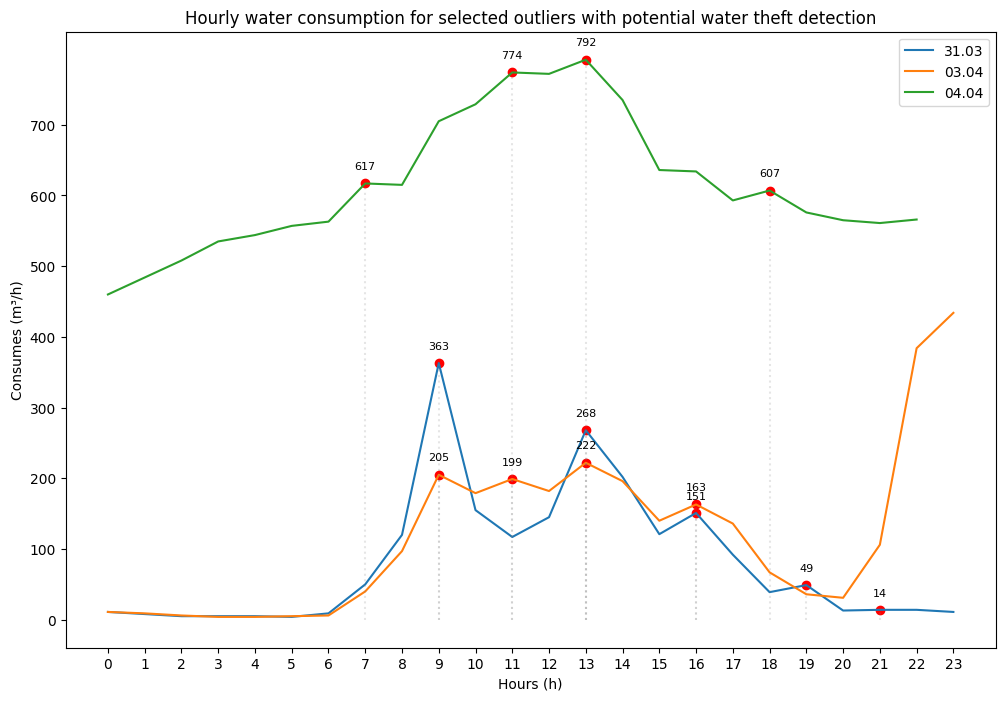

In [ ]:
# Define an array of selected dates
selected_dates = ['31.03', '03.04', '04.04']

# Find peaks in the data
peak_indices, _ = find_peaks(stolen_water['y'])
peaks = stolen_water.iloc[peak_indices]

# Map the selected dates to filter the data
filtered_data = stolen_water[stolen_water['Date'].dt.strftime('%d.%m').isin(selected_dates)]

plt.pyplot.figure(figsize=(12, 8))

# Plot the data for each selected date
for date in selected_dates:
    date_data = filtered_data[filtered_data['Date'].dt.strftime('%d.%m') == date]
    plt.pyplot.plot(date_data['Hour'], date_data['y'], label=date)

# Identify peaks (all local maxima)
peak_indices, _ = find_peaks(filtered_data['y'])
peaks = filtered_data.iloc[peak_indices]

# Annotate all peaks
for _, peak in peaks.iterrows():
    plt.pyplot.vlines(x=peak['Hour'], ymin=0, ymax=peak['y'], linestyles='dotted', colors='gray', alpha=0.2)
    plt.pyplot.scatter(peak['Hour'], peak['y'], color='red')
    plt.pyplot.annotate(f"{peak['y']}", 
                        (peak['Hour'], peak['y']), 
                        textcoords="offset points", 
                        xytext=(0, 10), 
                        ha='center', 
                        fontsize=8)

plt.pyplot.xlabel('Hours (h)', fontsize=10)
plt.pyplot.ylabel('Consumes (m³/h)', fontsize=10)

plt.pyplot.xticks(np.arange(0, filtered_data["Hour"].max() + 1, 1))
plt.pyplot.yticks(np.arange(0, filtered_data["y"].max() + 1, 100))

plt.pyplot.legend()
plt.pyplot.title('Hourly water consumption for selected outliers with potential water theft detection', fontsize=12)

plt.pyplot.show()

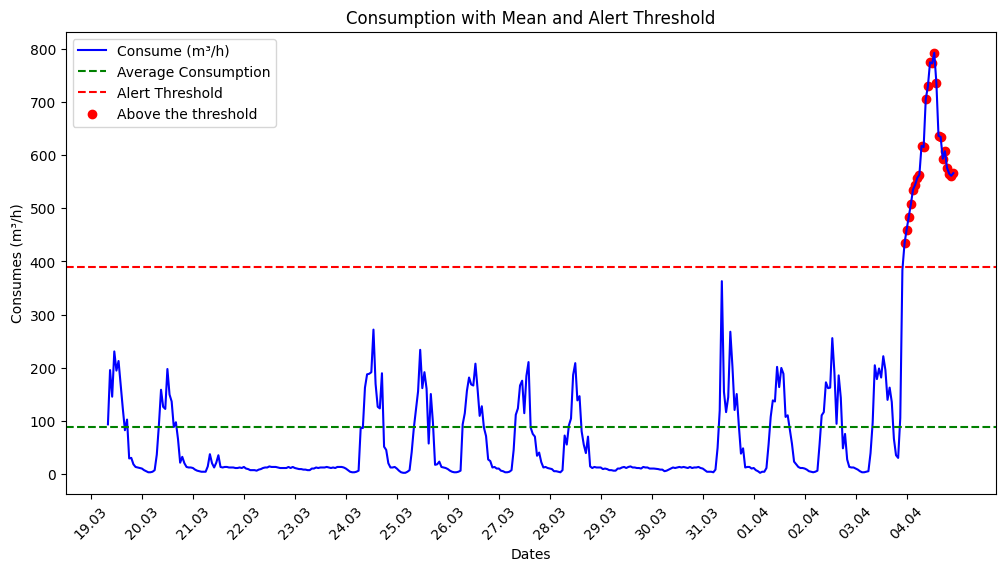

In [9]:
mean_consume = stolen_water['y'].mean()
std_consume = stolen_water['y'].std()
alert_threshold = mean_consume + 2 * std_consume

# Creăm plotul
plt.pyplot.figure(figsize=(12, 6))
sns.lineplot(data=stolen_water, x=stolen_water['x'], y='y', label='Consume (m³/h)', color='blue')

# Adăugăm linia pentru media consumului
plt.pyplot.axhline(mean_consume, color='green', linestyle='--', label='Average Consumption')

# Adăugăm linia pentru pragul de alertă
plt.pyplot.axhline(alert_threshold, color='red', linestyle='--', label='Alert Threshold')

# Identificăm și marcăm valorile peste prag
above_threshold = stolen_water[stolen_water['y'] > alert_threshold]
plt.pyplot.scatter(above_threshold['x'], above_threshold['y'], color='red', label='Above the threshold')

# Formatează axa X pentru a afișa datele în format DD.MM
unique_dates = stolen_water['x'].dt.date.drop_duplicates().sort_values()
formatted_dates = [pd.to_datetime(date).strftime('%d.%m') for date in unique_dates]
plt.pyplot.xticks(ticks=unique_dates, labels=formatted_dates, rotation=45)

# Adăugăm titlu, etichete și legendă
plt.pyplot.title('Consumption with Mean and Alert Threshold', fontsize=12)
plt.pyplot.xlabel('Dates', fontsize=10)
plt.pyplot.ylabel('Consumes (m³/h)', fontsize=10)
plt.pyplot.legend()

# Afișăm plotul
plt.pyplot.show()